# **Install tree_shade_mapper**

In [ ]:
# !pip install tree_shade_mapper --default-timeout=100

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of gradio to determine which version is compatible with other requirements. This could take a while.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of osmnx to determine which version is compatible with other requirements. This could take a while.
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of streetlevel to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of streetlevel to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver

In [ ]:
# Patch the installed zensvi file
import pathlib

p = pathlib.Path('/usr/local/lib/python3.12/dist-packages/zensvi/cv/segmentation/segmentation.py')
txt = p.read_text()

before = 'max_train_id = np.max(train_ids) + 1'
after  = 'max_train_id = int(np.max(train_ids)) + 1'

if before in txt:
    p.write_text(txt.replace(before, after))
    print('Patched zensvi segmentation.py')
else:
    print('Expected line not found; file may already be fixed')

# 2) Restart runtime (required so the patched module is reloaded)
import os, sys
os.kill(os.getpid(), 9)

# **Download sample data**

In [ ]:
import requests
import zipfile
import io
import os

def download_and_extract_zip(url, extract_path):
    # Convert GitHub blob URL to raw content URL
    raw_url = url.replace('github.com', 'raw.githubusercontent.com').replace('/blob/', '/')

    # Send a GET request to the URL
    response = requests.get(raw_url)

    # Check if the request was successful
    if response.status_code == 200:
        # Create a BytesIO object from the content
        zip_file = io.BytesIO(response.content)

        # Extract the contents of the zip file
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

        print(f"Successfully downloaded and extracted to {extract_path}")
    else:
        print(f"Failed to download the file. Status code: {response.status_code}")

# URL of the zip file
url = "https://github.com/kunifujiwara/data/blob/master/tree_shade_mapper/data.zip"

# Path where you want to extract the contents
extract_path = "extracted_data"

# Create the extract directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Call the function to download and extract
download_and_extract_zip(url, extract_path)

Successfully downloaded and extracted to extracted_data


# **Map sky view factor and solar irradiance**

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Weights downloaded to /usr/local/lib/python3.12/models/groundingdino/groundingdino_swint_ogc.pth
Using GPU


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `Mask2FormerImageProcessor.__init__` and were ignored: '_max_size', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/190M [00:00<?, ?B/s]

Processing outer batches of size 50: 100%|██████████| 1/1 [00:10<00:00, 10.33s/it]
/usr/local/lib/python3.12/dist-packages/tree_shade_mapper/solar_data_process.py:223: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  azimuth = (df_solar["azimuth"][j]+azimuth_offset)%360#degree
/usr/local/lib/python3.12/dist-packages/tree_shade_mapper/solar_data_process.py:224: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  zenith = df_solar["apparent_zenith"][j]#degree
/usr/local/lib/python3.12/dist-packages/tree_shade_mapper/solar_data_process.py:237: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futur

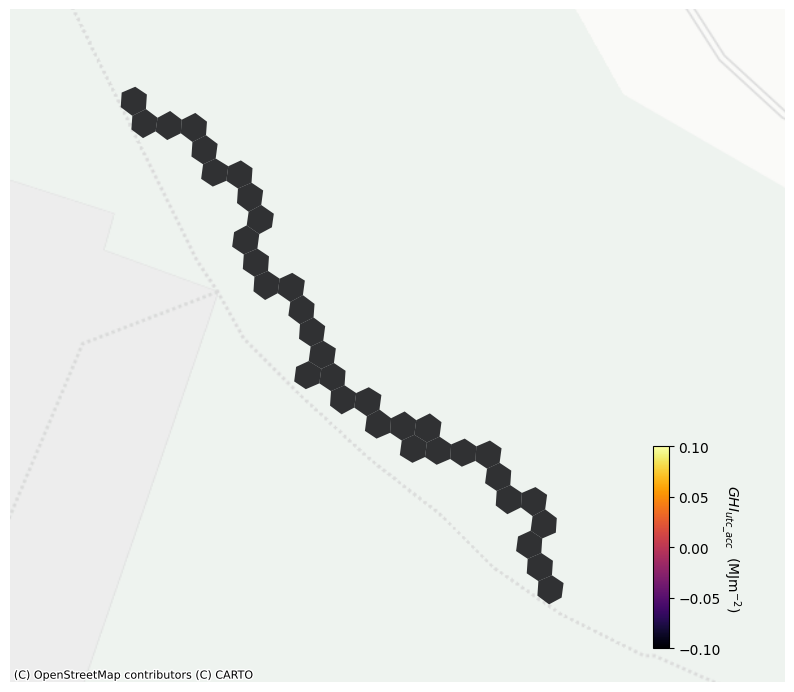

Colour column min value -0.0485704454773299, max value -0.0485704454773299, mean value -0.0485704454773299
Hexagon cell count: 34


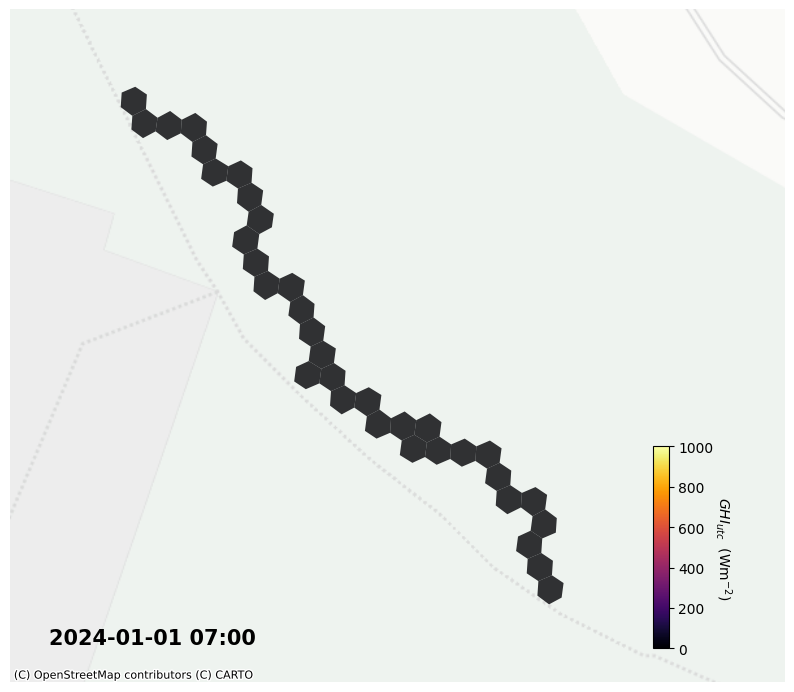

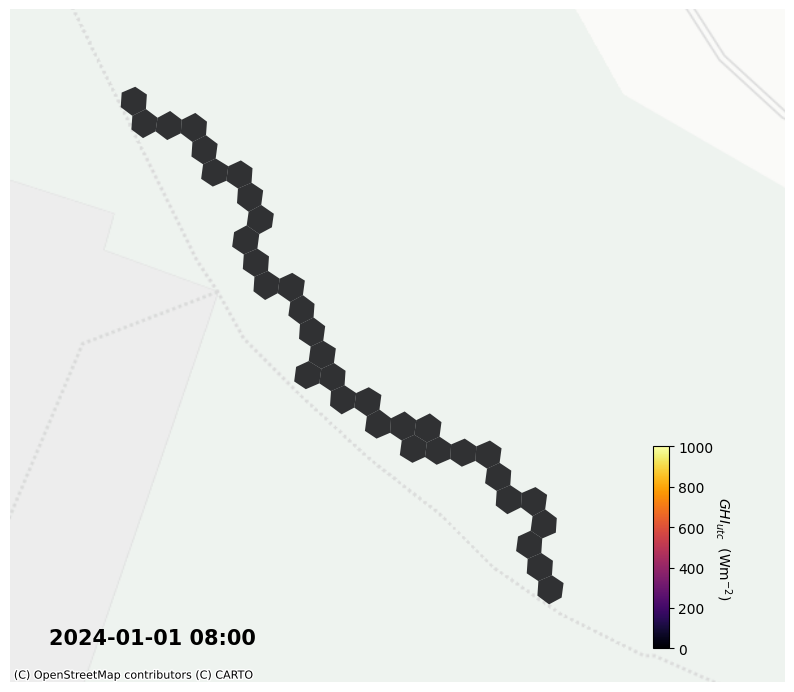

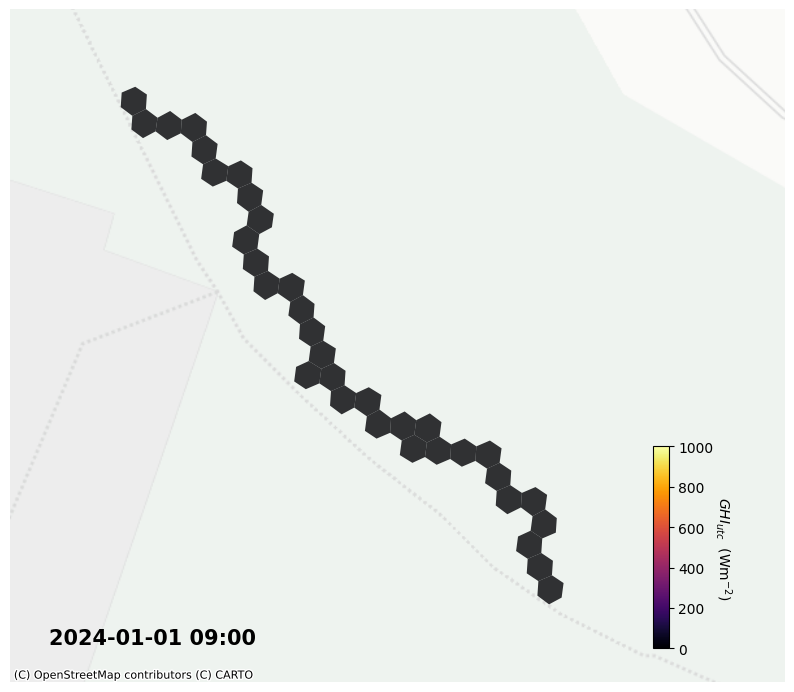

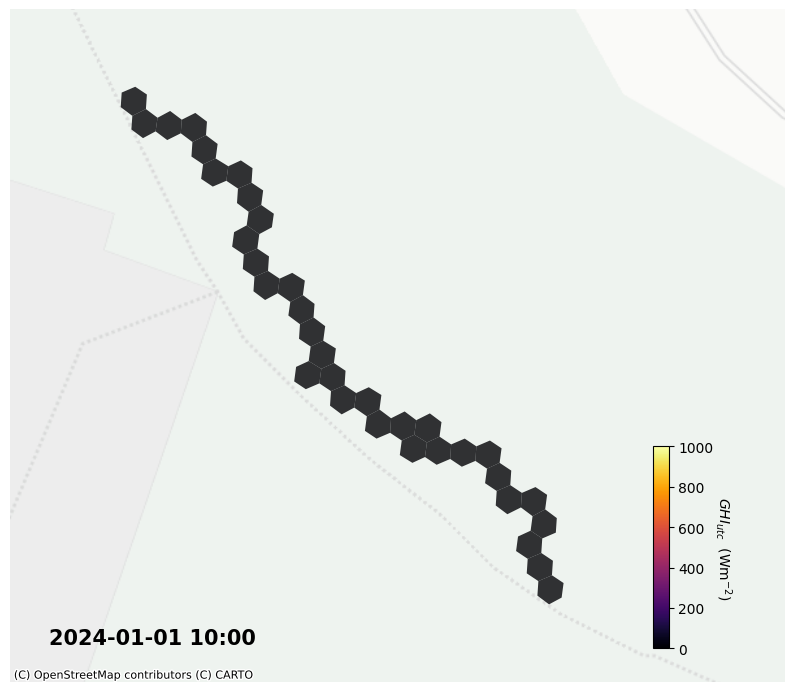

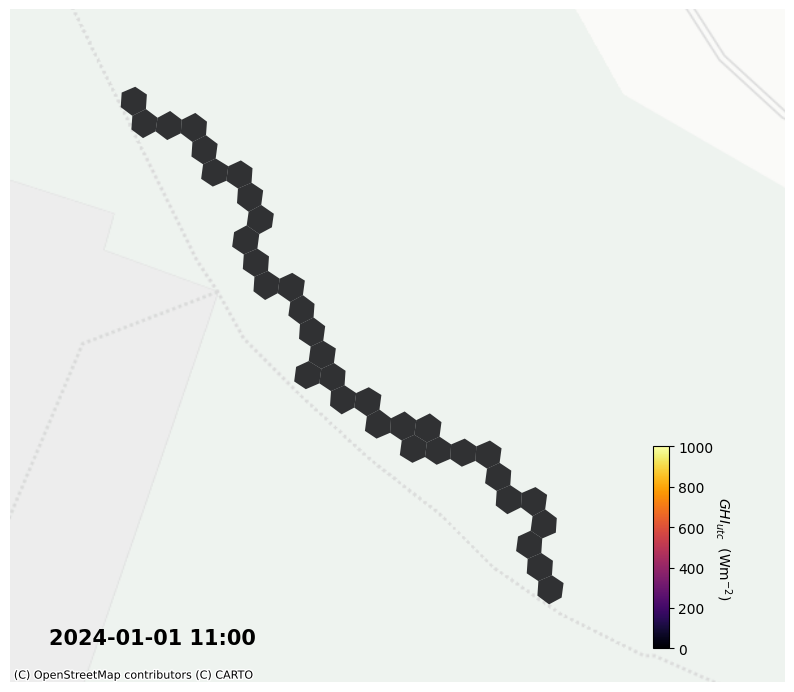

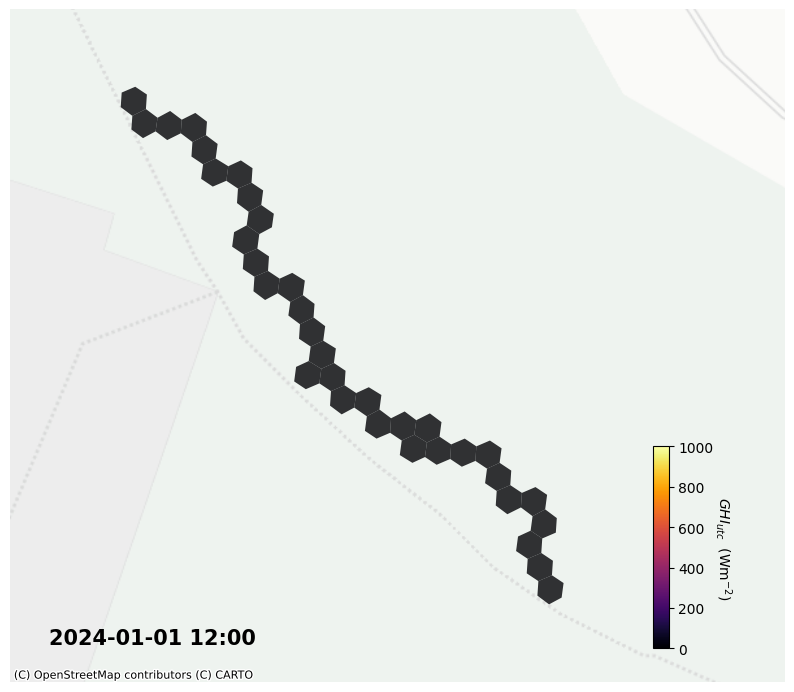

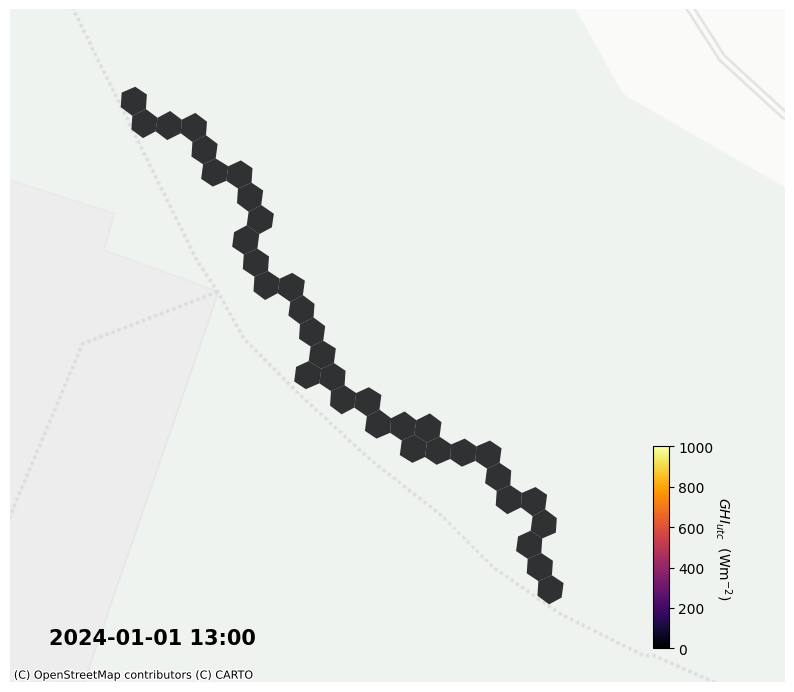

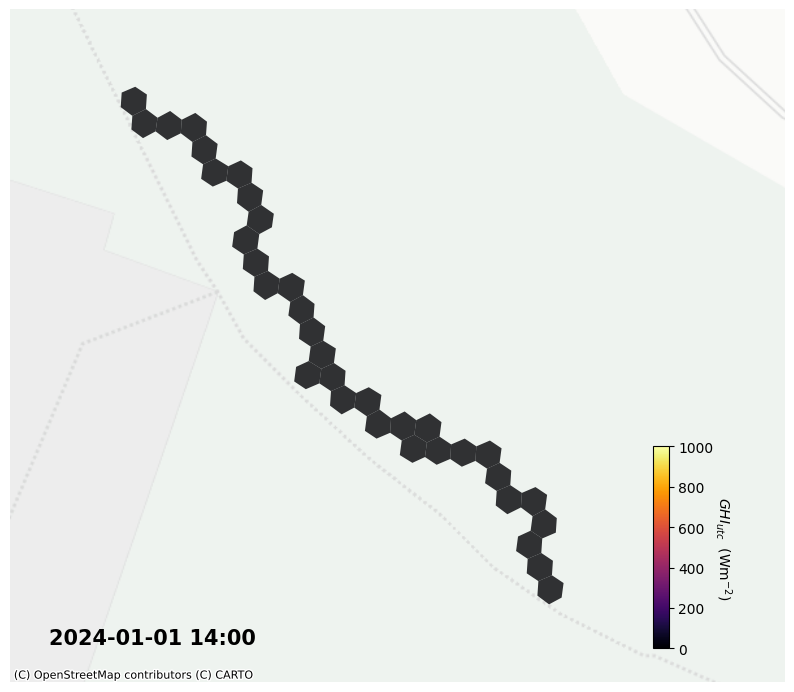

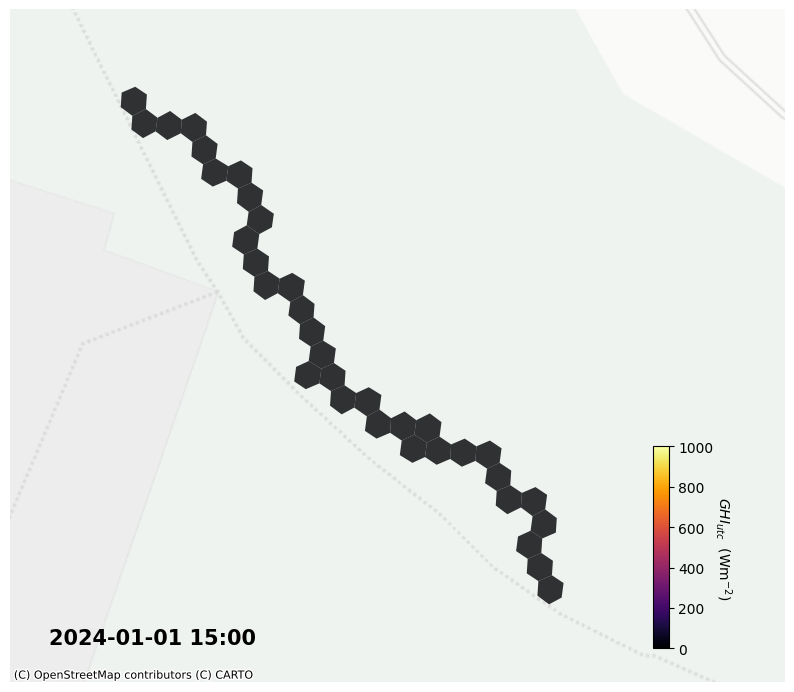

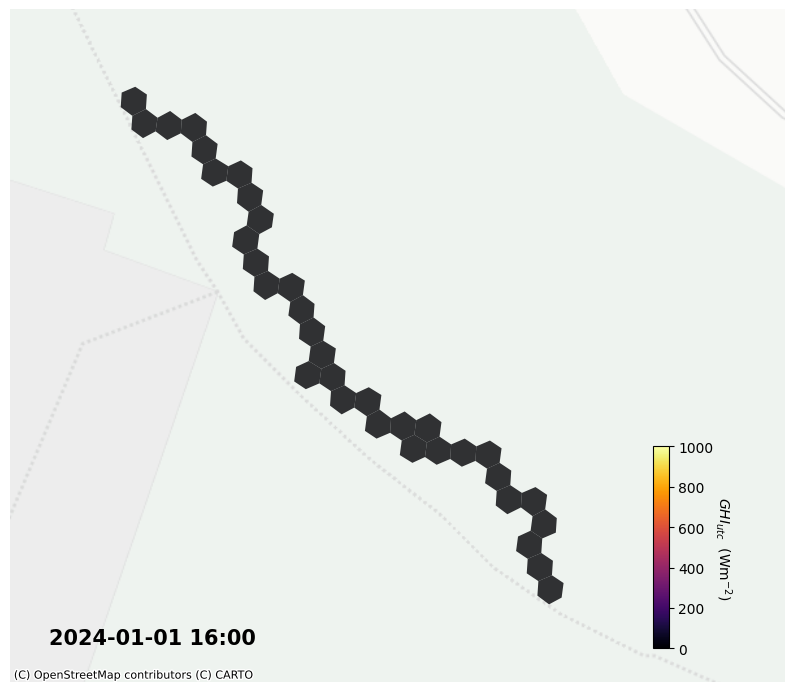

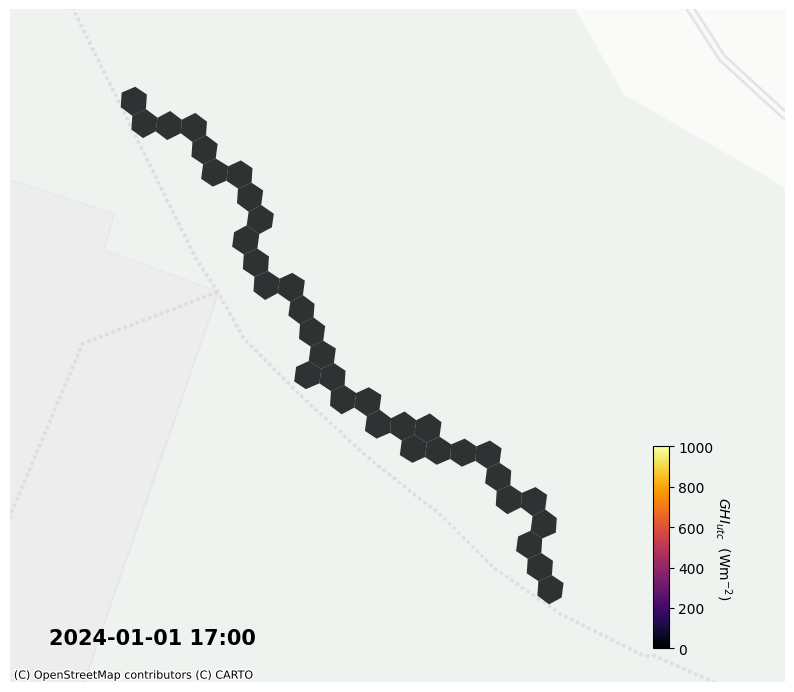

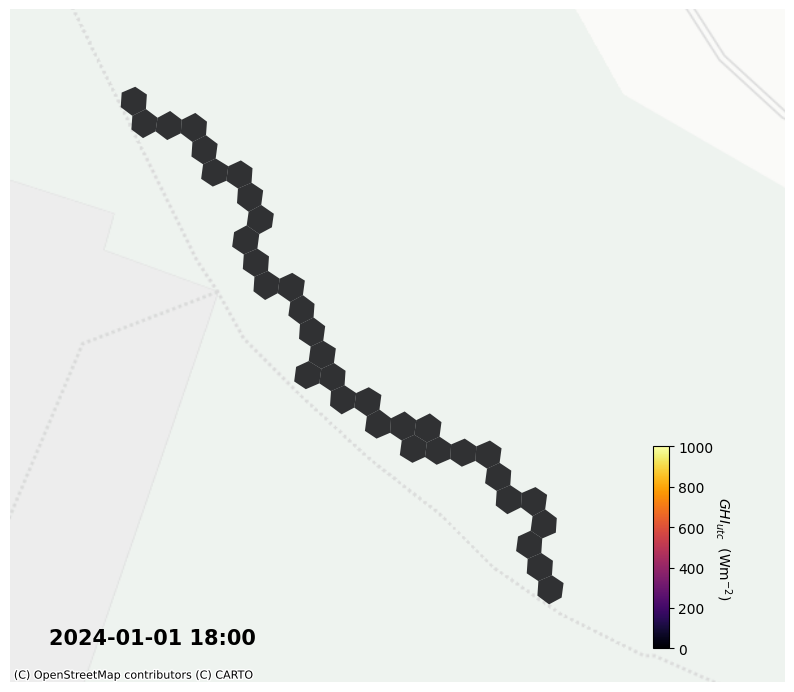

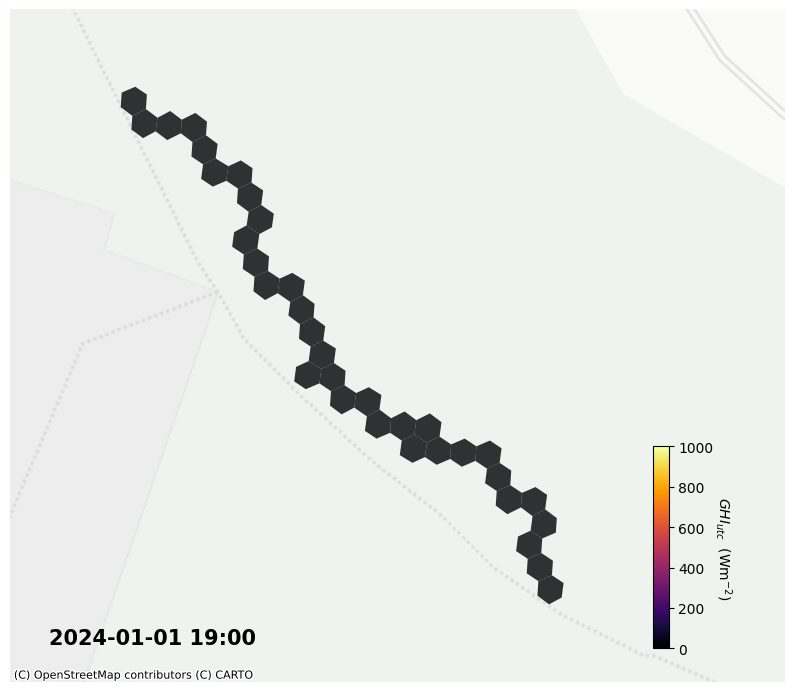

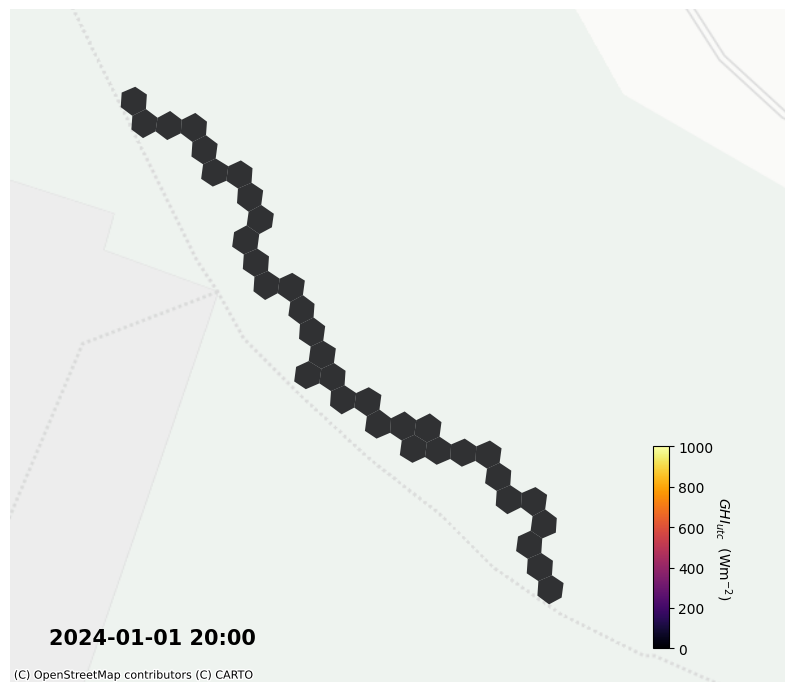

['ghi_utc_tcm_2024-01-01-18-00_map.png', 'ghi_utc_tcm_2024-01-01-12-00_map.png', 'ghi_utc_tcm_2024-01-01-15-00_map.png', 'ghi_utc_tcm_2024-01-01-10-00_map.png', 'ghi_utc_tcm_2024-01-01-17-00_map.png', 'ghi_utc_tcm_2024-01-01-16-00_map.png', 'ghi_utc_tcm_2024-01-01-13-00_map.png', 'ghi_utc_tcm_2024-01-01-11-00_map.png', 'ghi_utc_tcm_2024-01-01-14-00_map.png', 'ghi_utc_tcm_2024-01-01-07-00_map.png', 'ghi_utc_tcm_2024-01-01-09-00_map.png', 'ghi_utc_tcm_2024-01-01-20-00_map.png', 'ghi_utc_tcm_2024-01-01-19-00_map.png', 'ghi_utc_tcm_2024-01-01-08-00_map.png']


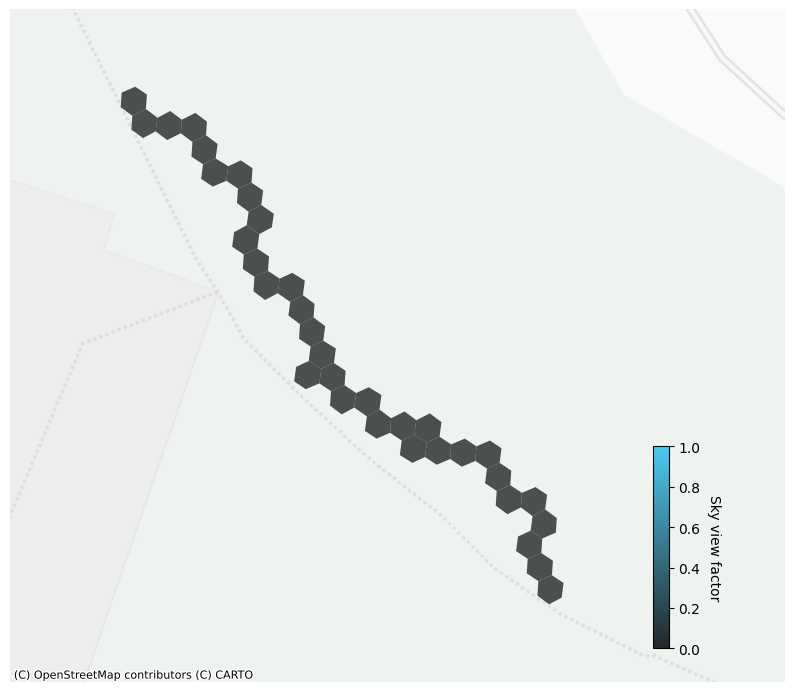

Colour column min value -0.00902438848506, max value -0.00902438848506, mean value -0.00902438848506
Hexagon cell count: 34
['GS013208_00200.jpg', 'GS013208_00175.jpg', 'GS013208_00182.jpg', 'GS013208_00205.jpg', 'GS013208_00171.jpg', 'GS013208_00163.jpg', 'GS013208_00172.jpg', 'GS013208_00194.jpg', 'GS013208_00176.jpg', 'GS013208_00174.jpg', 'GS013208_00160.jpg', 'GS013208_00162.jpg', 'GS013208_00186.jpg', 'GS013208_00177.jpg', 'GS013208_00191.jpg', 'GS013208_00157.jpg', 'GS013208_00197.jpg', 'GS013208_00156.jpg', 'GS013208_00189.jpg', 'GS013208_00164.jpg', 'GS013208_00168.jpg', 'GS013208_00193.jpg', 'GS013208_00187.jpg', 'GS013208_00173.jpg', 'GS013208_00184.jpg', 'GS013208_00165.jpg', 'GS013208_00198.jpg', 'GS013208_00159.jpg', 'GS013208_00167.jpg', 'GS013208_00181.jpg', 'GS013208_00169.jpg', 'GS013208_00183.jpg', 'GS013208_00204.jpg', 'GS013208_00192.jpg', 'GS013208_00201.jpg', 'GS013208_00199.jpg', 'GS013208_00170.jpg', 'GS013208_00203.jpg', 'GS013208_00185.jpg', 'GS013208_00161.j

In [ ]:
from tree_shade_mapper import get_tree_shade

base_dir = '/content/extracted_data/data'
calc_type = 'map'

# Define start and end time, and the interval
time_start = '2024-01-01 07:00:00'
time_end = '2024-01-01 20:00:00'
interval = '60min'

# Define time zone and location
time_zone = 'Asia/Singapore'
latitude = 1.29751
longitude = 103.77012

vmin = 0
vmax = 1200
resolution = 14

#image size (You need to adjust here checking the results)
image_size = (512, 256)

get_tree_shade(
    base_dir,
    time_start,
    time_end,
    interval,
    time_zone,
    latitude,
    longitude,
    image_size=image_size,
    calc_type=calc_type,
    vmin=vmin,
    vmax=vmax,
    resolution = resolution
)